# Iris Species Classification

Goal: build a classification model to predict iris species from sepal and petal measurements.
This notebook performs EDA, visualizes class separability, compares k-NN, Logistic Regression,
and Decision Tree models, reports accuracy/confusion matrix/precision/recall, and saves the best model.

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from iris_models import (
    DecisionTreeClassifier,
    KNNClassifier,
    LogisticRegressionClassifier,
    ScaledClassifier,
)

sns.set_theme(style="whitegrid")

DATA_PATH = Path("IRIS.csv")
ARTIFACTS_DIR = Path("artifacts")
MODEL_PATH = ARTIFACTS_DIR / "iris_best_model.joblib"
FEATURES = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
TARGET = "species"
ARTIFACTS_DIR.mkdir(exist_ok=True)

## Helper Functions

In [2]:
def train_test_split_stratified(df, test_size=0.2, random_state=42):
    rng = np.random.default_rng(random_state)
    train_parts = []
    test_parts = []
    for _, group in df.groupby(TARGET):
        indices = group.index.to_numpy().copy()
        rng.shuffle(indices)
        test_count = int(round(len(indices) * test_size))
        test_parts.append(df.loc[indices[:test_count]])
        train_parts.append(df.loc[indices[test_count:]])
    train_df = pd.concat(train_parts).sample(frac=1, random_state=random_state)
    test_df = pd.concat(test_parts).sample(frac=1, random_state=random_state)
    return train_df[FEATURES], test_df[FEATURES], train_df[TARGET], test_df[TARGET]


def accuracy_score(y_true, y_pred):
    return float(np.mean(np.asarray(y_true) == np.asarray(y_pred)))


def precision_recall_by_class(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    labels = sorted(np.unique(np.concatenate([y_true, y_pred])))
    rows = []
    for label in labels:
        true_positive = np.sum((y_true == label) & (y_pred == label))
        false_positive = np.sum((y_true != label) & (y_pred == label))
        false_negative = np.sum((y_true == label) & (y_pred != label))
        precision = true_positive / (true_positive + false_positive) if true_positive + false_positive else 0.0
        recall = true_positive / (true_positive + false_negative) if true_positive + false_negative else 0.0
        rows.append({"species": label, "precision": precision, "recall": recall})
    return pd.DataFrame(rows)


def confusion_matrix_df(y_true, y_pred):
    labels = sorted(np.unique(np.concatenate([np.asarray(y_true), np.asarray(y_pred)])))
    matrix = pd.DataFrame(0, index=labels, columns=labels)
    for actual, predicted in zip(y_true, y_pred):
        matrix.loc[actual, predicted] += 1
    return matrix

## Load Data

In [3]:
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [5]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [6]:
print("Missing values:")
print(df.isna().sum())
print("\nClass counts:")
print(df[TARGET].value_counts())

Missing values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Class counts:
species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


## EDA And Class Separability

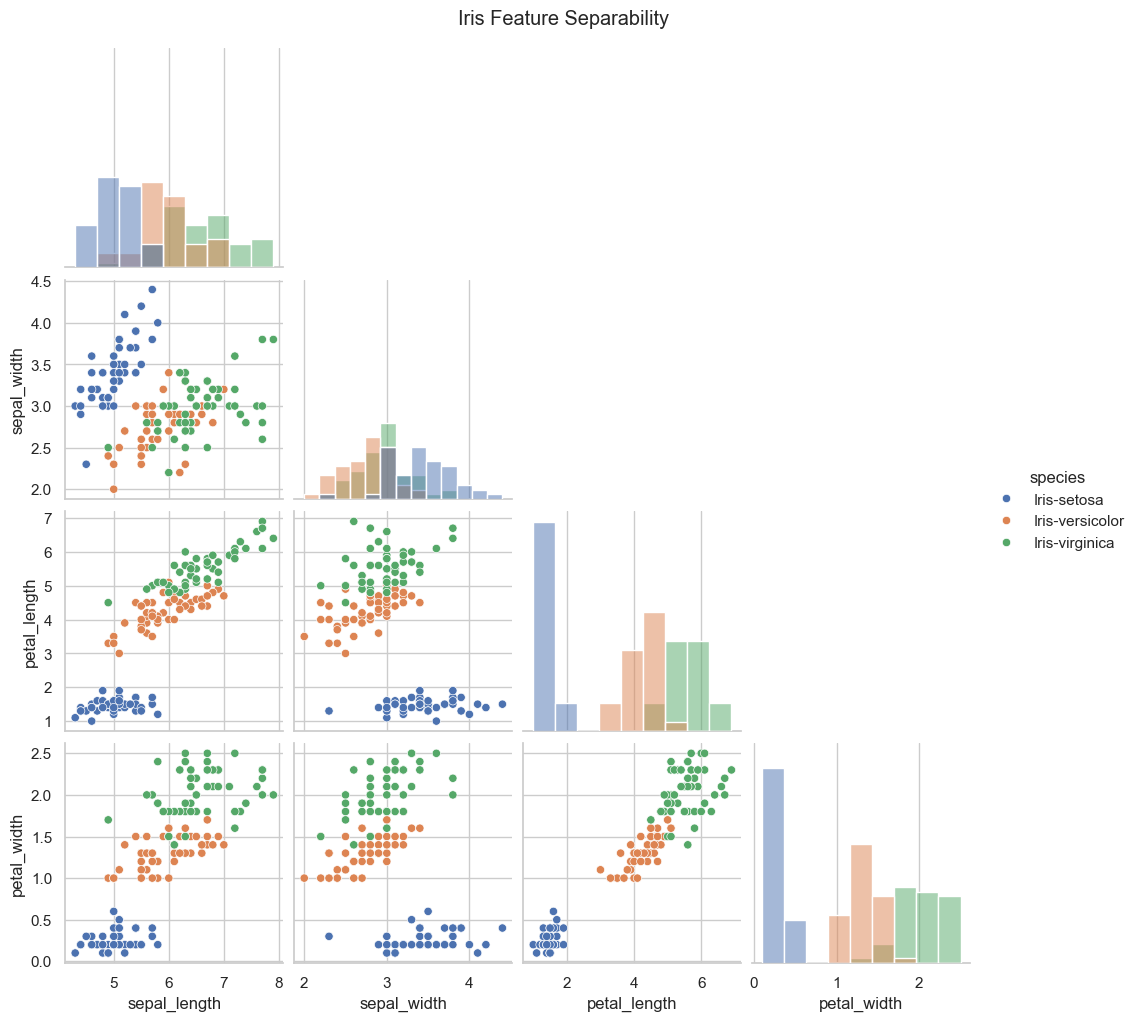

In [7]:
pairplot = sns.pairplot(df, hue=TARGET, diag_kind="hist", corner=True)
pairplot.fig.suptitle("Iris Feature Separability", y=1.02)
pairplot.savefig(ARTIFACTS_DIR / "iris_pairplot.png", dpi=160, bbox_inches="tight")
plt.show()

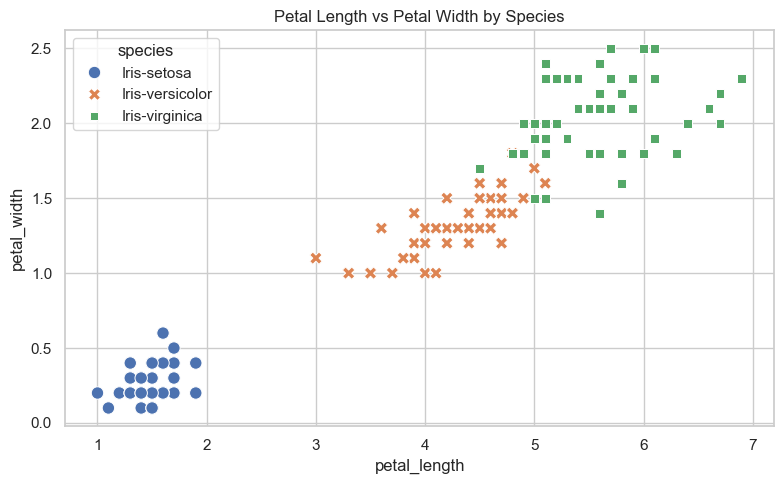

In [8]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="petal_length",
    y="petal_width",
    hue=TARGET,
    style=TARGET,
    s=80,
)
plt.title("Petal Length vs Petal Width by Species")
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "petal_scatter.png", dpi=160)
plt.show()

## Train/Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split_stratified(df)
X_train.shape, X_test.shape

((120, 4), (30, 4))

## Train And Compare Algorithms

In [10]:
models = {
    "k-NN": ScaledClassifier(KNNClassifier(n_neighbors=5)),
    "Logistic Regression": ScaledClassifier(
        LogisticRegressionClassifier(learning_rate=0.1, epochs=4000, random_state=42)
    ),
    "Decision Tree": DecisionTreeClassifier(max_depth=4),
}

results = []
fitted_models = {}
predictions_by_model = {}

for name, model in models.items():
    model.fit(X_train.to_numpy(), y_train.to_numpy())
    predictions = model.predict(X_test.to_numpy())
    pr = precision_recall_by_class(y_test.to_numpy(), predictions)
    results.append(
        {
            "model": name,
            "accuracy": accuracy_score(y_test.to_numpy(), predictions),
            "precision_macro": pr["precision"].mean(),
            "recall_macro": pr["recall"].mean(),
        }
    )
    fitted_models[name] = model
    predictions_by_model[name] = predictions

results_df = pd.DataFrame(results).sort_values(
    by=["accuracy", "precision_macro", "recall_macro", "model"],
    ascending=[False, False, False, True],
)
results_df.to_csv(ARTIFACTS_DIR / "model_comparison.csv", index=False)
results_df

,model,accuracy,precision_macro,recall_macro
1,Logistic Regression,1.000000,1.000000,1.000000
0,k-NN,0.966667,0.969697,0.966667
2,Decision Tree,0.933333,0.944444,0.933333


## Best Model Metrics

In [11]:
best_name = results_df.iloc[0]["model"]
best_model = fitted_models[best_name]
best_predictions = predictions_by_model[best_name]

print("Best model:", best_name)
print("Accuracy:", accuracy_score(y_test.to_numpy(), best_predictions))

per_class_report = precision_recall_by_class(y_test.to_numpy(), best_predictions)
per_class_report

Best model: Logistic Regression
Accuracy: 1.0


,species,precision,recall
0,Iris-setosa,1.0,1.0
1,Iris-versicolor,1.0,1.0
2,Iris-virginica,1.0,1.0


In [12]:
cm = confusion_matrix_df(y_test.to_numpy(), best_predictions)
cm

,Iris-setosa,Iris-versicolor,Iris-virginica
Iris-setosa,10,0,0
Iris-versicolor,0,10,0
Iris-virginica,0,0,10


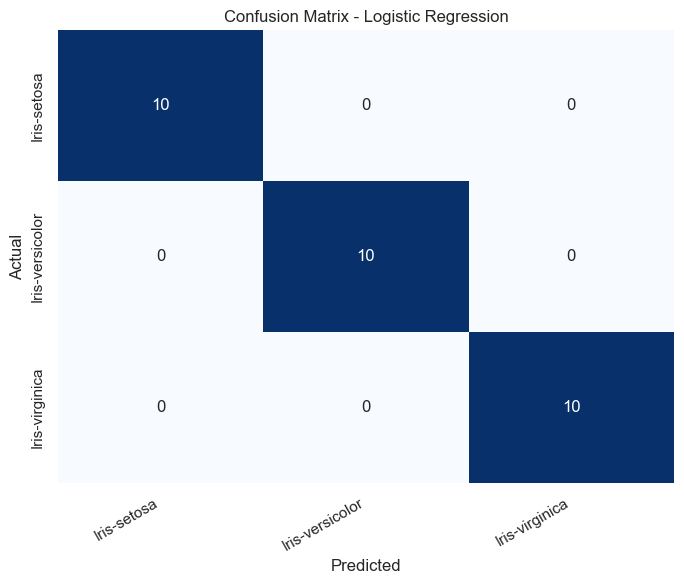

In [13]:
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title(f"Confusion Matrix - {best_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "confusion_matrix.png", dpi=160)
plt.show()

## Save Best Model

In [14]:
joblib.dump(best_model, MODEL_PATH)
MODEL_PATH

WindowsPath('artifacts/iris_best_model.joblib')

## Example Inference

In [15]:
loaded_model = joblib.load(MODEL_PATH)
sample = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns=FEATURES,
)
loaded_model.predict(sample.to_numpy())[0]

'Iris-setosa'